In [ ]:
import math
import matplotlib.pyplot as plt
import numpy as np
%matplotlib inline
def sigmoid(z):
    return 1 / (1 + math.exp(-z))


x = 4.0
y = -6.0
w1 = 0.5
w2 = -1.0
b = 1.0

z=x*w1 + y*w2 + b
print(z)
sigmoid(z)


9.0


0.9998766054240137

In [ ]:
class Neuron:
    def __init__(self, weights, bias):
        self.weights = weights
        self.bias = bias

    def forward(self, inputs):
        total = 0
        for w, x in zip(self.weights, inputs):
            total += w * x
        total += self.bias
        return sigmoid(total)


n=Neuron([2.0, 0.5], 0.5)
sonuc= n.forward([2, 3])
sonuc

0.9975273768433653

In [ ]:
class Layer:
  def __init__(self, weights_list, bias_list):
    self.weights_list=weights_list
    self.bias_list=bias_list
    self.neurons=[]

    for w, b in zip(self.weights_list, self.bias_list):
      self.neurons.append(Neuron(w, b))

  def forward(self, inputs):
   outputs=[]
   for neuron in self.neurons:
    outputs.append(neuron.forward(inputs))
   return outputs

katman=Layer([[2.0, 0.5], [1.0, -1.0]], [0.5, 0.0])
sonuc=katman.forward([2, 3])
sonuc

[0.9975273768433653, 0.2689414213699951]

In [ ]:
def loss(tahmin, gercek):
  return((tahmin-gercek)**2)


n = Neuron([0.5, -0.2], 0.1)
inputs = [1.0, 2.0]
gercek = 0.8

tahmin= n.forward(inputs)
sonuc_loss= loss(tahmin, gercek)
sonuc_loss


0.06258302890065331

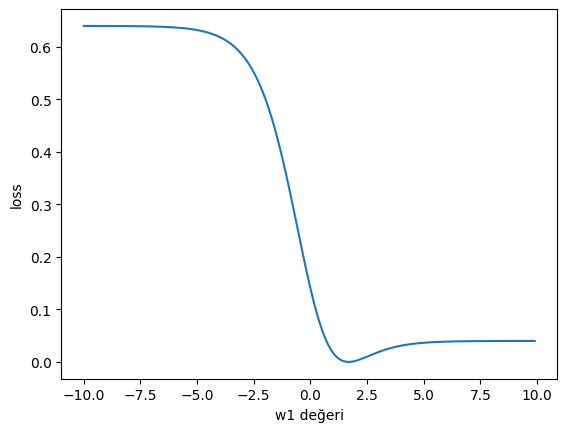

In [ ]:
def loss(tahmin, gercek):
  return((tahmin-gercek)**2)


n = Neuron([0.5, -0.2], 0.1)
inputs = [1.0, 2.0]
gercek = 0.8

w1_degerleri= np.arange(-10, 10, 0.1)
loss_degerleri=[]

for w1 in w1_degerleri:
  n.weights[0]=w1
  tahmin= n.forward(inputs)
  loss_degerleri.append(loss(tahmin, gercek))

plt.plot(w1_degerleri, loss_degerleri)
plt.xlabel("w1 değeri")
plt.ylabel("loss")
plt.show()


In [ ]:
h=0.0001
w1_ilk=-8.0
n.weights[0]=w1_ilk
tahmin1=n.forward(inputs)
loss1=loss(tahmin1, gercek)
n.weights[0] = w1_ilk + h
tahmin2 = n.forward(inputs)
loss2 = loss(tahmin2, gercek)
turev = (loss2 - loss1) / h
turev


-0.00039732578338558255

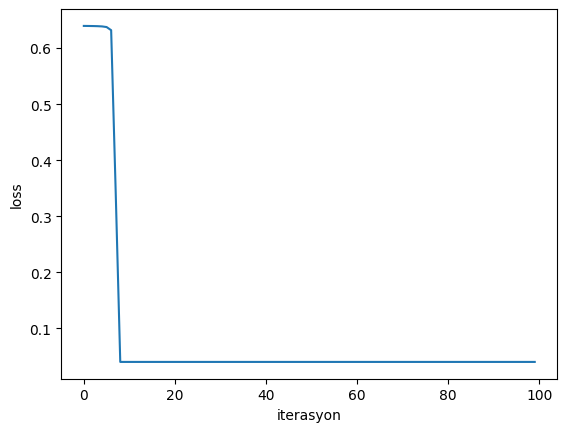

In [ ]:
w1= -8.0
learning_rate=1000
adim_sayisi=100
loss_gecmisi=[]

for i in range(adim_sayisi):
  n.weights[0]=w1
  tahmin=n.forward(inputs)
  loss1=loss(tahmin, gercek)
  loss_gecmisi.append(loss(tahmin, gercek))

  n.weights[0]=w1+h
  tahmin2=n.forward(inputs)
  loss2=loss(tahmin2, gercek)

  turev=(loss2-loss1)/h
  w1=w1-learning_rate*turev

plt.plot(loss_gecmisi)
plt.xlabel("iterasyon")
plt.ylabel("loss")
plt.show()


